In [18]:
!pip install kaggle

In [19]:
import os
os.environ['KAGGLE_API_TOKEN']='KGAT_1c28811cf90f075699872d8713163d5a'

In [20]:
!pip install kagglehub

In [21]:
import kagglehub

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print(path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
/kaggle/input/plantvillage-dataset


In [22]:
import os

dataset_path = "/kaggle/input/plantvillage-dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", len(dirs))
    print("Files:", len(files))
    break

/kaggle/input/plantvillage-dataset
Folders: 1
Files: 0


In [23]:
!ls /kaggle/input/plantvillage-dataset

'plantvillage dataset'


In [24]:
import os

data_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [25]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

train_ds, val_ds = dataset

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Using 10861 files for validation.


In [26]:
class_names = train_ds.class_names
print(class_names)
print("Number of classes:", len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [27]:
import os

base_path = "/kaggle/input/plantvillage-dataset/plantvillage dataset"

print(os.listdir(base_path))

['segmented', 'grayscale', 'color']


In [28]:
import os

color_path = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

print(os.listdir(color_path)[:20])
print("Total classes:", len(os.listdir(color_path)))

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot']
Total classes: 38


In [29]:
print(train_ds.class_names)
print("Number of classes:", len(train_ds.class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [30]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [32]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [34]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [35]:
print(model)

<Sequential name=sequential_1, built=True>


In [36]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 204s 144ms/step - accuracy: 0.7022 - loss: 1.0422 - val_accuracy: 0.8573 - val_loss: 0.4703
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.8856 - loss: 0.3627 - val_accuracy: 0.8914 - val_loss: 0.3454
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.9340 - loss: 0.2065 - val_accuracy: 0.8982 - val_loss: 0.3524
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 93s 68ms/step - accuracy: 0.9546 - loss: 0.1334 - val_accuracy: 0.8993 - val_loss: 0.3777
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 86s 63ms/step - accuracy: 0.9676 - loss: 0.0969 - val_accuracy: 0.8850 - val_loss: 0.5226
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - accuracy: 0.9746 - loss: 0.0779 - val_accuracy: 0.8830 - val_loss: 0.4989
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 143s 64ms/step - accuracy: 0.9751 - loss: 0.0755 - val_accuracy: 0.9034 - val_loss: 0.4589
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 63ms/step - accuracy: 0.9

In [37]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9068 - loss: 0.4406
Validation Accuracy: 0.9068225622177124


In [38]:
model.save("plant_disease_model.h5")

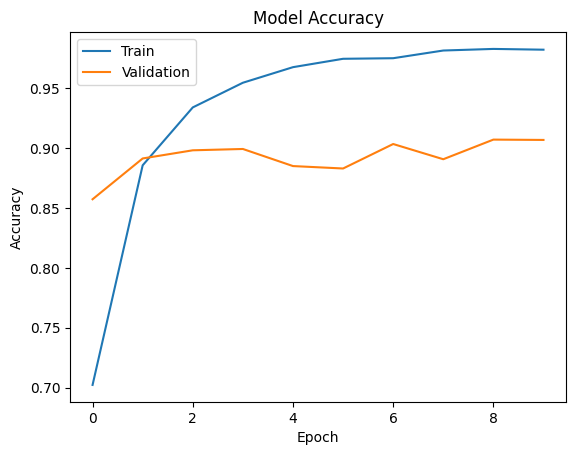

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [40]:
from google.colab import files

files.download("plant_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>